In [87]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt
from dataclasses import dataclass
from scipy.linalg import solve, cho_factor, cho_solve

# Модуль 1: Вспомогательные функции и утилиты

In [88]:
# -*- coding: utf-8 -*-
"""
Модуль 1: Вспомогательные функции и утилиты
===========================================

Этот модуль содержит базовые утилитарные функции для генерации случайных чисел,
линейной алгебры и преобразований матриц, используемые в Gibbs-сэмплере.
"""

def _rng(rng: np.random.Generator) -> np.random.Generator:
    """
    Вспомогательная функция для управления генератором случайных чисел.

    Parameters
    ----------
    rng : np.random.Generator | None
        Генератор случайных чисел или None

    Returns
    -------
    np.random.Generator
        Активный генератор случайных чисел
    """
    return rng if rng is not None else np.random.default_rng()


def chol_upper_r(m: np.ndarray) -> np.ndarray:
    """
    Верхний треугольный Холецкий фактор такой, что U.T @ U = m.

    Parameters
    ----------
    m : np.ndarray
        Симметричная положительно определенная матрица

    Returns
    -------
    np.ndarray
        Верхняя треугольная матрица Холецкого
    """
    c, low = cho_factor(m, lower=False, check_finite=False)
    return c if not low else c.T


def chol2inv_upper(u: np.ndarray) -> np.ndarray:
    """
    Обращение матрицы через верхний треугольный Холецкий фактор.

    Parameters
    ----------
    u : np.ndarray
        Верхняя треугольная матрица Холецкого

    Returns
    -------
    np.ndarray
        Обратная матрица
    """
    ident = np.eye(u.shape[0])
    return cho_solve((u, False), ident, check_finite=False)


def rgamma_rate(rng: np.random.Generator, shape: float, rate: float) -> float:
    """
    Генерация случайного числа из гамма-распределения с параметром rate.

    Parameters
    ----------
    rng : np.random.Generator
        Генератор случайных чисел
    shape : float
        Параметр формы
    rate : float
        Параметр скорости (rate = 1/scale)

    Returns
    -------
    float
        Случайное число из гамма-распределения
    """
    return float(rng.gamma(shape, scale=1.0 / rate))


def rinvgauss_r(rng: np.random.Generator, mean: float, dispersion: float) -> float:
    """
    Генерация случайного числа из обратного гауссовского распределения.

    Parameters
    ----------
    rng : np.random.Generator
        Генератор случайных чисел
    mean : float
        Среднее значение
    dispersion : float
        Параметр дисперсии

    Returns
    -------
    float
        Случайное число из обратного гауссовского распределения
    """
    return float(stats.invgauss.rvs(mean, scale=dispersion, random_state=rng))


def rwish_mcmcpack(rng: np.random.Generator, df: int, scale: np.ndarray) -> np.ndarray:
    """
    Генерация случайной матрицы из распределения Уишарта.

    Parameters
    ----------
    rng : np.random.Generator
        Генератор случайных чисел
    df : int
        Степени свободы
    scale : np.ndarray
        Масштабная матрица

    Returns
    -------
    np.ndarray
        Случайная матрица из распределения Уишарта
    """
    return stats.wishart.rvs(df=df, scale=scale, random_state=rng)


def rmvn(rng: np.random.Generator, mean: np.ndarray, cov: np.ndarray) -> np.ndarray:
    """
    Генерация случайного вектора из многомерного нормального распределения.

    Parameters
    ----------
    rng : np.random.Generator
        Генератор случайных чисел
    mean : np.ndarray
        Вектор средних
    cov : np.ndarray
        Ковариационная матрица

    Returns
    -------
    np.ndarray
        Случайный вектор
    """
    return rng.multivariate_normal(mean, cov, check_valid="ignore")

# Модуль 2: Настройка структуры модели CFA

In [89]:
# -*- coding: utf-8 -*-
"""
Модуль 2: Настройка структуры модели CFA
========================================

Функции для задания структуры факторных нагрузок (LY) в модели
конфирматорного факторного анализа (CFA) с байесовским ковариационным Lasso.
"""

def set_ly_int(cir: int, idy0: np.ndarray) -> np.ndarray:
    """
    Инициализация матрицы факторных нагрузок на основе индикаторной матрицы.

    Parameters
    ----------
    cir : int
        Тип инициализации (1, 2 или другое)
    idy0 : np.ndarray
        Индикаторная матрица с значениями:
        9 - фиксированная нагрузка = 1
        1 - свободная нагрузка
        -1 - фиксированная нагрузка = 0.1
        0 - нулевая нагрузка

    Returns
    -------
    np.ndarray
        Инициализированная матрица нагрузок
    """
    ny, nz = idy0.shape
    ly = np.full((ny, nz), 0.1)

    for i in range(ny):
        for j in range(nz):
            v = idy0[i, j]
            if v == 9:
                ly[i, j] = 1.0
            elif v == 1:
                if cir == 1:
                    ly[i, j] = 1.0
                elif cir == 2:
                    ly[i, j] = 0.9
                else:
                    ly[i, j] = 1.1
            elif v == -1:
                ly[i, j] = 0.1
            else:
                ly[i, j] = 0.0
    return ly


def idy_for_gibbs(idy0: np.ndarray) -> np.ndarray:
    """
    Преобразование индикаторной матрицы для использования в Gibbs-сэмплере.

    Parameters
    ----------
    idy0 : np.ndarray
        Исходная индикаторная матрица

    Returns
    -------
    np.ndarray
        Преобразованная матрица (значения 9 заменяются на 0)
    """
    idy = idy0.copy()
    idy[idy0 == 9] = 0.0
    return idy

# Модуль 3: Вспомогательные функции для матричных операций

In [90]:
"""
Модуль 3: Вспомогательные функции для матричных операций
=========================================================

Функции для работы с индексами матриц и преобразованиями, необходимыми
для реализации графического Lasso-алгоритма в Gibbs-сэмплере.
"""

import numpy as np

def _r_upper_lower_indices(ny: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Создание индексов для верхней и нижней треугольных частей матрицы.

    Parameters
    ----------
    ny : int
        Размер матрицы

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Индексы для верхней и нижней треугольных частей
    """
    indmx = np.arange(1, ny * ny + 1).reshape(ny, ny, order="F")
    ui, uj = np.triu_indices(ny, k=1)
    upperind = indmx[ui, uj].astype(int)
    indmx_t = indmx.T
    li, lj = np.triu_indices(ny, k=1)
    lowerind = indmx_t[li, lj].astype(int)
    return upperind, lowerind


def _set_tau_r_linear(tau: np.ndarray, r_indices: np.ndarray,
                      tau_temp: np.ndarray, ny: int) -> None:
    """
    Заполнение матрицы tau значениями из вектора tau_temp.

    Parameters
    ----------
    tau : np.ndarray
        Целевая матрица
    r_indices : np.ndarray
        Индексы для заполнения
    tau_temp : np.ndarray
        Вектор значений
    ny : int
        Размер матрицы
    """
    for k, idx in enumerate(r_indices):
        j = (int(idx) - 1) // ny
        i = (int(idx) - 1) % ny
        tau[i, j] = tau_temp[k]


def _inv_psx_upper_values(inv_psx: np.ndarray, upperind: np.ndarray,
                          ny: int) -> np.ndarray:
    """
    Извлечение верхней треугольной части обратной ковариационной матрицы.

    Parameters
    ----------
    inv_psx : np.ndarray
        Обратная ковариационная матрица
    upperind : np.ndarray
        Индексы верхней треугольной части
    ny : int
        Размер матрицы

    Returns
    -------
    np.ndarray
        Вектор значений верхней треугольной части
    """
    out = np.zeros(len(upperind))
    for k, idx in enumerate(upperind):
        j = (idx - 1) // ny
        i = (idx - 1) % ny
        out[k] = inv_psx[i, j]
    return out

# Модуль 4: Основной Gibbs-сэмплер

In [91]:
# -*- coding: utf-8 -*-
"""
Модуль 4: Основной Gibbs-сэмплер для байесовского CFA с ковариационным Lasso
=============================================================================

Реализация основного алгоритма Gibbs-сэмплинга для байесовской модели
конфирматорного факторного анализа с графическим Lasso-априором
на ковариационную матрицу остатков.
"""

import numpy as np
from scipy.linalg import solve, cho_factor, cho_solve
from typing import Optional, Dict, Any


def gibbs_psx_fun(
    mcmax: int,
    nz: int,
    ny: int,
    n: int,
    y: np.ndarray,
    ly_int: np.ndarray,
    idy0: np.ndarray,
    idy: np.ndarray,
    nthin: int,
    n_burn: int,
    cir: int = 1,
    rng: Optional[np.random.Generator] = None,
) -> Dict[str, np.ndarray]:
    """
    Gibbs-сэмплер для байесовского CFA с ковариационным Lasso.

    Реализует алгоритм из Pan, Ip & Dubé (2017) для оценки параметров
    модели конфирматорного факторного анализа с априором Graphical Lasso
    на ковариационную матрицу остатков.
    """

    # Вспомогательные функции
    def _rng(rng):
        return rng if rng is not None else np.random.default_rng()

    def chol_upper_r(m):
        c, low = cho_factor(m, lower=False, check_finite=False)
        return c if not low else c.T

    def chol2inv_upper(u):
        ident = np.eye(u.shape[0])
        return cho_solve((u, False), ident, check_finite=False)

    def rgamma_rate(rng, shape, rate):
        return float(rng.gamma(shape, scale=1.0 / rate))

    def rinvgauss_r(rng, mean, dispersion):
        from scipy import stats
        return float(stats.invgauss.rvs(mean, scale=dispersion, random_state=rng))

    def rwish_mcmcpack(rng, df, scale):
        from scipy import stats
        return stats.wishart.rvs(df=df, scale=scale, random_state=rng)

    def rmvn(rng, mean, cov):
        return rng.multivariate_normal(mean, cov, check_valid="ignore")

    def _r_upper_lower_indices(ny):
        indmx = np.arange(1, ny * ny + 1).reshape(ny, ny, order="F")
        ui, uj = np.triu_indices(ny, k=1)
        upperind = indmx[ui, uj].astype(int)
        indmx_t = indmx.T
        li, lj = np.triu_indices(ny, k=1)
        lowerind = indmx_t[li, lj].astype(int)
        return upperind, lowerind

    def _set_tau_r_linear(tau, r_indices, tau_temp, ny):
        for k, idx in enumerate(r_indices):
            j = (int(idx) - 1) // ny
            i = (int(idx) - 1) % ny
            tau[i, j] = tau_temp[k]

    def _inv_psx_upper_values(inv_psx, upperind, ny):
        out = np.zeros(len(upperind))
        for k, idx in enumerate(upperind):
            j = (idx - 1) // ny
            i = (idx - 1) % ny
            out[k] = inv_psx[i, j]
        return out

    rng = _rng(rng)

    # Настройка параметров модели
    idmu = np.ones(ny, dtype=bool)
    idmua = bool(idmu.any())
    nm = 0
    nk = nm + nz
    omega = np.zeros((nk, n))
    nmu = int(idmu.sum())
    nly = int(idy.sum())
    nrec = mcmax // nthin

    # Инициализация массивов для сохранения результатов
    emu = np.zeros((nrec, nmu))
    ely = np.zeros((nrec, nly))
    epsx = np.zeros((nrec, ny, ny))
    einvpsx = np.zeros((nrec, ny, ny))
    ephi = np.zeros((nrec, nz * nz))
    epostp = np.zeros(nrec)

    # Подготовка индексов
    upperind, lowerind = _r_upper_lower_indices(ny)

    # Инициализация параметров
    ind_noi_all = np.zeros((ny - 1, ny), dtype=int)
    for ii in range(ny):
        if ii == 0:
            ind_noi = np.arange(1, ny)
        elif ii == ny - 1:
            ind_noi = np.arange(0, ny - 1)
        else:
            ind_noi = np.concatenate([np.arange(0, ii), np.arange(ii + 1, ny)])
        ind_noi_all[:, ii] = ind_noi

    # Гиперпараметры
    ply = np.zeros((ny, nz))
    ply[idy0 == 9] = 1.0
    pmu = np.zeros(ny)
    sigly = 0.25
    sigmu = 0.25
    rou_scale = 6.0
    rou_zero = rou_scale + nz + 1
    r_zero = rou_scale * np.eye(nz)
    a_lambda = 1.0
    b_lambda = 0.01

    # Начальные значения параметров
    ly = ly_int.astype(float).copy()
    mu = np.ones(ny)
    phi = np.zeros((nz, nz))
    np.fill_diagonal(phi, 1.0)
    xi = rng.multivariate_normal(np.zeros(nz), phi, size=n).T
    psx = np.zeros((ny, ny))
    np.fill_diagonal(psx, 1.0)
    inv_phi = chol2inv_upper(chol_upper_r(phi))
    inv_psx = chol2inv_upper(chol_upper_r(psx))
    inv_sqrt_psx = chol_upper_r(inv_psx)

    if not idmua:
        mu[:] = 0.0

    # Обработка пропущенных значений
    missing_ind = np.zeros((ny, n), dtype=int)
    y_work = y.astype(float).copy()
    for i in range(ny):
        for j in range(n):
            if np.isnan(y_work[i, j]):
                missing_ind[i, j] = 1
                y_work[i, j] = rng.standard_normal()

    # Основной цикл Gibbs-сэмплинга
    tau = np.zeros((ny, ny))
    chainpsx = np.zeros((nrec, ny * (ny + 1) // 2))
    y_missing = np.zeros((ny, n, nrec))

    for g in range(1, mcmax + 1):
        gm = g
        gm2 = g - n_burn

        # 1. Генерация латентных факторов (Omega)
        q = inv_sqrt_psx @ ly
        isg = q.T @ q + inv_phi
        sig = solve(isg, np.eye(nz), check_finite=False)
        ycen = y_work - mu[:, None] if idmua else y_work.copy()
        mean_om = sig @ (ly.T @ inv_psx @ ycen)
        for i in range(n):
            omega[:, i] = xi[:, i] = rmvn(rng, mean_om[:, i], sig)

        # 2. Генерация средних (MU)
        if idmua:
            calsm = solve(
                n * inv_psx + np.diag(np.full(ny, sigmu)),
                np.eye(ny),
                check_finite=False,
            )
            ycen2 = y_work - ly @ omega
            temp = ycen2.sum(axis=1)
            mumu = calsm @ (inv_psx @ temp + sigmu * pmu)
            mu = rmvn(rng, mumu, calsm)

        # 3. Генерация ковариационной матрицы остатков (PSX) с Graphical Lasso
        temp_res = y_work - mu[:, None] - ly @ omega
        s_mat = temp_res @ temp_res.T

        apost = a_lambda + ny * (ny + 1) / 2
        bpost = b_lambda + np.abs(inv_psx).sum() / 2
        lam = rgamma_rate(rng, apost, bpost)

        cadjust = np.maximum(_inv_psx_upper_values(inv_psx, upperind, ny), 1e-6)
        mu_prime = np.minimum(lam / cadjust, 1e12)
        lambda_prime = lam**2
        tau_temp = np.zeros(len(mu_prime))
        for ii in range(len(mu_prime)):
            tau_temp[ii] = 1.0 / rinvgauss_r(
                rng, mu_prime[ii], 1.0 / lambda_prime
            )
        _set_tau_r_linear(tau, upperind, tau_temp, ny)
        _set_tau_r_linear(tau, lowerind, tau_temp, ny)

        # Блочное обновление PSX
        for i in range(ny):
            ind_noi = ind_noi_all[:, i]
            tau_temp1 = tau[ind_noi, i]
            sig11 = psx[np.ix_(ind_noi, ind_noi)]
            sig12 = psx[ind_noi, i]
            invc11 = sig11 - np.outer(sig12, sig12) / psx[i, i]
            ci = (s_mat[i, i] + lam) * invc11 + np.diag(1.0 / tau_temp1)
            sigma_blk = chol2inv_upper(chol_upper_r(ci))
            mu_i = -sigma_blk @ s_mat[ind_noi, i]
            beta = rmvn(rng, mu_i, sigma_blk)
            inv_psx[np.ix_(ind_noi, [i])] = beta.reshape(-1, 1)
            inv_psx[np.ix_([i], ind_noi)] = beta.reshape(1, -1)
            gam = rgamma_rate(rng, n / 2 + 1, (s_mat[i, i] + lam) / 2)
            inv_psx[i, i] = gam + float(beta @ invc11 @ beta)

            invc11beta = invc11 @ beta
            psx[np.ix_(ind_noi, ind_noi)] = invc11 + np.outer(invc11beta, invc11beta) / gam
            sig12_new = -invc11beta / gam
            psx[np.ix_(ind_noi, [i])] = sig12_new.reshape(-1, 1)
            psx[np.ix_([i], ind_noi)] = sig12_new.reshape(1, -1)
            psx[i, i] = 1.0 / gam

        inv_sqrt_psx = chol_upper_r(inv_psx)

        # 4. Генерация факторных нагрузок (LY)
        count_n = 1
        for j in range(ny):
            subs = idy[j, :] == 1
            lens = int(subs.sum())
            if lens > 0:
                idx_j = np.arange(ny) != j
                psx_jj = psx[np.ix_(idx_j, idx_j)]
                temp1 = chol2inv_upper(chol_upper_r(psx_jj))

                # Условное среднее y_j при заданных y_{-j}
                ycen = y_work[j] - mu[j]
                not_subs = ~subs
                # Корректный учет влияния других факторов и ковариации остатков
                ycen = (
                    ycen
                    - ly[j, not_subs] @ omega[not_subs, :]
                    - psx[j, idx_j] @ temp1 @ (y_work[idx_j] - mu[idx_j, None] - ly[idx_j, :] @ omega)
                )

                omesub = omega[subs, :] # (lens, n)
                psiginv = np.diag(np.full(lens, sigly))
                pmean = ply[j, subs].reshape(-1, 1) # Явно в столбец (lens, 1)

                convar = psx[j, j] - psx[j, idx_j] @ temp1 @ psx[idx_j, j]
                invconvar = 1.0 / float(convar)

                # Информационная матрица (точность)
                omesub_omesub_T = omesub @ omesub.T
                temp_matrix = invconvar * omesub_omesub_T + psiginv
                calsmnpsx = chol2inv_upper(chol_upper_r(temp_matrix))

                # Апостериорное среднее
                # (lens, n) @ (n, 1) -> (lens, 1)
                omy = (omesub @ ycen.reshape(-1, 1)) * invconvar
                temp_m = omy + psiginv @ pmean

                lynpsx = (calsmnpsx @ temp_m).ravel()
                ly[j, subs] = rmvn(rng, lynpsx, calsmnpsx)

                if gm > 0 and gm % nthin == 0:
                    gm_row = gm // nthin - 1
                    ely[gm_row, count_n - 1 : count_n - 1 + lens] = ly[j, subs]

                count_n += lens

        # 5. Генерация ковариационной матрицы факторов (PHI)
        a_mat = omega @ omega.T + r_zero
        inv_phi = rwish_mcmcpack(rng, rou_zero + n, np.linalg.inv(a_mat))
        phi = chol2inv_upper(chol_upper_r(inv_phi))

        # 6. Импутация пропущенных значений
        for jj in range(ny):
            for ii in range(n):
                if missing_ind[jj, ii] == 1:
                    idx = np.arange(ny) != jj
                    sj = psx[np.ix_(idx, idx)]
                    cf = cho_factor(sj, lower=True)
                    mjj = (
                        mu[jj]
                        + ly[jj, :] @ omega[:, ii]
                        + psx[jj, idx]
                        @ cho_solve(cf, y_work[idx, ii] - mu[idx] - ly[idx, :] @ omega[:, ii])
                    )
                    vjj = psx[jj, jj] - psx[jj, idx] @ cho_solve(cf, psx[idx, jj])
                    y_work[jj, ii] = rng.normal(mjj, np.sqrt(float(vjj)))

        # Сохранение результатов
        if gm > 0 and gm % nthin == 0:
            gm_store = gm // nthin - 1
            ephi[gm_store, :] = phi.ravel()
            epsx[gm_store, :, :] = psx
            einvpsx[gm_store, :, :] = inv_psx
            emu[gm_store, :] = mu

            k = 0
            for ii in range(ny):
                for jj in range(ny):
                    if ii >= jj:
                        chainpsx[gm_store, k] = psx[ii, jj]
                        k += 1

            # Расчет Posterior Predictive P-value
            if gm2 > 0:
                postp1 = 0.0
                postp2 = 0.0
                y_cen = y_work - mu[:, None] - ly @ omega
                for ii in range(n):
                    postp1 += float(y_cen[:, ii] @ inv_psx @ y_cen[:, ii])

                xi_temp = rng.multivariate_normal(np.zeros(nz), phi, size=n).T
                theta_temp = mu[:, None] + ly @ xi_temp
                y_temp = np.zeros((ny, n))
                for ii in range(n):
                    y_temp[:, ii] = rmvn(rng, theta_temp[:, ii], psx)

                y_cen2 = y_temp - mu[:, None] - ly @ xi_temp
                y_missing[:, :, gm_store] = y_temp
                for ii in range(n):
                    postp2 += float(y_cen2[:, ii] @ inv_psx @ y_cen2[:, ii])

                if postp1 <= postp2 and gm_store < nrec:
                    epostp[gm_store] = 1.0

    return {
        "EMU": emu,
        "ELY": ely,
        "EPHI": ephi,
        "EPSX": epsx,
        "Epostp": epostp,
        "EinvPSX": einvpsx,
        "chainpsx": chainpsx,
        "missing_ind": missing_ind,
        "Y_missing": y_missing,
    }

# Модуль 5: Постобработка результатов

In [92]:
"""
Модуль 5: Постобработка результатов
===================================

Функции для анализа и визуализации результатов Gibbs-сэмплинга,
включая расчет апостериорных средних и Posterior Predictive P-values.
"""

@dataclass
class PosteriorSummary:
    """
    Класс для хранения результатов постобработки.

    Attributes
    ----------
    mean_psx : np.ndarray
        Апостериорное среднее ковариационной матрицы остатков
    ppp : float
        Posterior Predictive P-value
    """
    mean_psx: np.ndarray
    ppp: float


def summarize_psx(chain: dict[str, np.ndarray], n_burn: int, mcmax: int, nthin: int) -> PosteriorSummary:
    """
    Расчет апостериорного среднего и PPP с учетом прореживания (thinning).
    """
    # Рассчитываем, с какого индекса в СОХРАНЕННОМ массиве начинается burn-in
    burn_idx = n_burn // nthin

    # Берем все, что после прогрева
    epsx = chain["EPSX"][burn_idx:]

    if epsx.size == 0:
        return PosteriorSummary(mean_psx=np.array([]), ppp=float("nan"))

    mean_psx = epsx.mean(axis=0)

    ep = chain["Epostp"]
    # Для PPP также используем индекс от n_burn
    tail = ep[burn_idx:]
    ppp = float(np.mean(tail)) if tail.size else float("nan")

    return PosteriorSummary(mean_psx=mean_psx, ppp=ppp)


def compute_credible_intervals(chain: dict[str, np.ndarray],
                               param_name: str,
                               n_burn: int,
                               ci_level: float = 0.95) -> tuple[np.ndarray, np.ndarray]:
    """
    Расчет кредибельных интервалов для выбранного параметра.

    Parameters
    ----------
    chain : dict[str, np.ndarray]
        Словарь с сохраненными значениями из Gibbs-сэмплера
    param_name : str
        Название параметра ('EPSX', 'EPHI', 'ELY', 'EMU')
    n_burn : int
        Количество итераций разогрева
    ci_level : float, optional
        Уровень кредибельного интервала (по умолчанию 0.95)

    Returns
    -------
    tuple[np.ndarray, np.ndarray]
        Нижняя и верхняя границы кредибельного интервала
    """
    samples = chain[param_name][n_burn:]
    alpha = (1 - ci_level) / 2
    lower = np.percentile(samples, alpha * 100, axis=0)
    upper = np.percentile(samples, (1 - alpha) * 100, axis=0)
    return lower, upper

# Модуль 6: Пример использования

Пример байесовского CFA с ковариационным Lasso

Размер данных: 6 переменных, 200 наблюдений
Количество факторов: 2
Структура нагрузок:
[[9. 0.]
 [1. 0.]
 [0. 9.]
 [0. 1.]
 [1. 1.]
 [1. 1.]]

Запуск Gibbs-сэмплера...
Сэмплирование завершено!

Posterior Predictive P-value: 0.5350


<Axes: title={'center': 'Апостериорное среднее Ψ'}, xlabel='Переменные'>

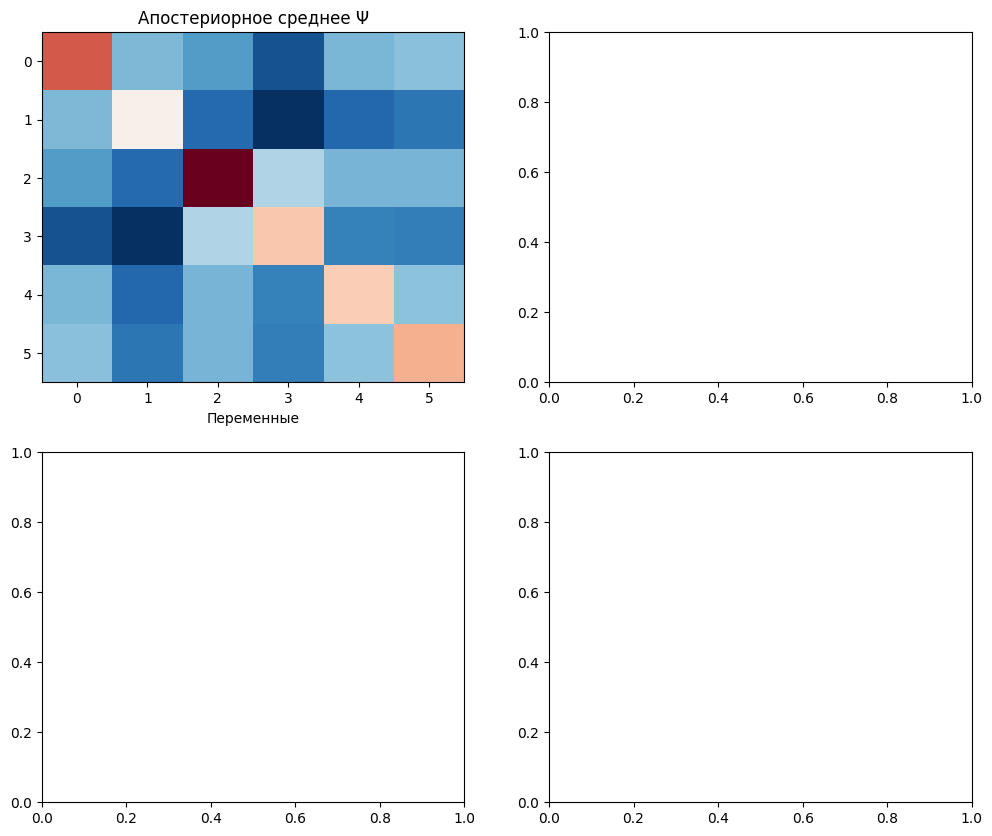

In [93]:
"""
Модуль 6: Пример использования
==============================

Демонстрация работы Gibbs-сэмплера на синтетических данных.
"""

def generate_synthetic_data(n=100, ny=6, nz=2, seed=42):
    """
    Генерация синтетических данных для тестирования.

    Parameters
    ----------
    n : int
        Размер выборки
    ny : int
        Количество наблюдаемых переменных
    nz : int
        Количество факторов
    seed : int
        Зерно для генератора случайных чисел

    Returns
    -------
    tuple
        Наблюдаемые данные, истинные параметры и индикаторные матрицы
    """
    rng = np.random.default_rng(seed)

    # Истинные параметры
    true_ly = np.array([
        [1.0, 0.0],  # y1 нагрузка на фактор 1
        [0.8, 0.0],  # y2 нагрузка на фактор 1
        [0.0, 1.0],  # y3 нагрузка на фактор 2
        [0.0, 0.9],  # y4 нагрузка на фактор 2
        [0.5, 0.5],  # y5 нагрузка на оба фактора
        [0.6, 0.4],  # y6 нагрузка на оба фактора
    ])

    true_phi = np.array([[1.0, 0.5], [0.5, 1.0]])
    true_psx = np.diag(np.ones(ny)) * 0.5

    # Генерация данных
    xi = rng.multivariate_normal(np.zeros(nz), true_phi, size=n).T
    epsilon = rng.multivariate_normal(np.zeros(ny), true_psx, size=n).T
    y = true_ly @ xi + epsilon

    # Индикаторные матрицы
    idy0 = np.zeros((ny, nz))
    idy0[0, 0] = 9  # Фиксированная нагрузка = 1
    idy0[1, 0] = 1  # Свободная нагрузка
    idy0[2, 1] = 9  # Фиксированная нагрузка = 1
    idy0[3, 1] = 1  # Свободная нагрузка
    idy0[4, 0] = 1  # Свободная нагрузка
    idy0[4, 1] = 1  # Свободная нагрузка
    idy0[5, 0] = 1  # Свободная нагрузка
    idy0[5, 1] = 1  # Свободная нагрузка

    return y, true_ly, true_phi, true_psx, idy0


# Пример использования
print("=" * 60)
print("Пример байесовского CFA с ковариационным Lasso")
print("=" * 60)

# Генерация данных
n, ny, nz = 200, 6, 2
y, true_ly, true_phi, true_psx, idy0 = generate_synthetic_data(n, ny, nz)
idy = idy_for_gibbs(idy0)
ly_int = set_ly_int(1, idy0)

print(f"\nРазмер данных: {ny} переменных, {n} наблюдений")
print(f"Количество факторов: {nz}")
print(f"Структура нагрузок:\n{idy0}")

# Запуск Gibbs-сэмплера
print("\nЗапуск Gibbs-сэмплера...")
mcmax = 5000
n_burn = 1000
nthin = 5

results = gibbs_psx_fun(
    mcmax=mcmax,
    nz=nz,
    ny=ny,
    n=n,
    y=y,
    ly_int=ly_int,
    idy0=idy0,
    idy=idy,
    nthin=nthin,
    n_burn=n_burn,
    cir=1,
    rng=np.random.default_rng(42)
)

print("Сэмплирование завершено!")

# Анализ результатов
summary = summarize_psx(results, n_burn, mcmax, nthin)
print(f"\nPosterior Predictive P-value: {summary.ppp:.4f}")

# Визуализация
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Апостериорное среднее ковариационной матрицы остатков
ax = axes[0, 0]
im = ax.imshow(summary.mean_psx, cmap='RdBu_r', aspect='auto')
ax.set_title('Апостериорное среднее Ψ')
ax.set_xlabel('Переменные')
ax

In [95]:
df = pd.read_csv('simu_data.txt', sep=None, header=None, engine='python')
y_real = df.values.T
ny, n = y_real.shape
print(f"Загружено переменных: {ny}, наблюдений: {n}")


nz = 2
idy0 = np.full((ny, nz), -1.0)

# Указываем структуру (Основные нагрузки)
idy0[0, 0] = 9; idy0[1:5, 0] = 1
idy0[5, 1] = 9; idy0[6:10, 1] = 1

idy = idy_for_gibbs(idy0)
ly_int = set_ly_int(1, idy0)

y_mean = y_real.mean(axis=1, keepdims=True)
y_std = y_real.std(axis=1, keepdims=True)
y_standardized = (y_real - y_mean) / y_std

results = gibbs_psx_fun(
    mcmax=5000,
    nz=nz,
    ny=ny,
    n=n,
    y=y_standardized,
    ly_int=ly_int,
    idy0=idy0,
    idy=idy,
    nthin=5,
    n_burn=2000,
    rng=np.random.default_rng(1)
)

# Используем исправленный сумматор
summary = summarize_psx(results, n_burn=2000, mcmax=5000, nthin=5)

print(f"PPP (у R-пакета было ~0.51): {summary.ppp:.4f}")
print("\nСредние нагрузки (ELY):")
# Выведем среднее для первой колонки нагрузок (после burn-in)
print(results["ELY"][400:].mean(axis=0))

Загружено переменных: 10, наблюдений: 500


ValueError: negative dimensions are not allowed